In [2]:
import pandas as pd 

df = pd.read_csv(r"C:\Users\91727\OneDrive\Desktop\logistics_delivery_cleaned.csv")

print("Rows:", df.shape[0])
print("Columns:",df.shape[1])

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum().sum())

df.head()

Rows: 25000
Columns: 18

Columns:
['delivery_id', 'delivery_partner', 'package_type', 'vehicle_type', 'delivery_mode', 'region', 'weather_condition', 'distance_km', 'package_weight_kg', 'delivery_time_hours', 'expected_time_hours', 'delayed', 'delivery_status', 'delivery_rating', 'delivery_cost', 'distance_km_normalized', 'package_weight_kg_normalized', 'delivery_cost_normalized']

Missing values:
0


,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delayed,delivery_status,delivery_rating,delivery_cost,distance_km_normalized,package_weight_kg_normalized,delivery_cost_normalized
0,250.99,delhivery,automobile parts,bike,same day,west,clear,297.0,46.96,8,8,no,delivered,3,1632.7206,0.999659,0.947595,1.000000
1,250.99,xpressbees,cosmetics,ev van,express,central,cold,89.6,47.39,2,3,no,delivered,5,640.1700,0.293015,0.956397,0.354251
2,250.99,shadowfax,groceries,truck,two day,east,rainy,273.5,26.89,10,16,no,delivered,4,1448.1700,0.919591,0.536745,0.879932
3,250.99,dhl,electronics,ev van,same day,east,cold,269.7,12.69,6,8,no,delivered,3,1486.5700,0.906644,0.246059,0.904915
4,250.99,dhl,clothing,van,two day,north,foggy,256.7,37.02,9,16,no,delivered,4,1394.5600,0.862351,0.744115,0.845054


In [3]:
# Target variable
target = "delivery_time_hours"

# Features we will use for prediction
features = [
    "delivery_partner",
    "package_type",
    "vehicle_type",
    "delivery_mode",
    "region",
    "weather_condition",
    "distance_km",
    "package_weight_kg"
]

X = df[features]
y = df[target]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features:
['delivery_partner', 'package_type', 'vehicle_type', 'delivery_mode', 'region', 'weather_condition', 'distance_km', 'package_weight_kg']

Target:
delivery_time_hours

X shape: (25000, 8)
y shape: (25000,)


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (20000, 8)
Testing features: (5000, 8)
Training target: (20000,)
Testing target: (5000,)


In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    "delivery_partner",
    "package_type",
    "vehicle_type",
    "delivery_mode",
    "region",
    "weather_condition"
]

numerical_features = [
    "distance_km",
    "package_weight_kg"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [6]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

# Train the model
linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make predictions on unseen test data
y_pred_linear = linear_model.predict(X_test)

# Calculate evaluation metrics
mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

print("===== LINEAR REGRESSION RESULTS =====")
print("MAE :", round(mae_linear, 2), "hours")
print("RMSE:", round(rmse_linear, 2), "hours")
print("R²  :", round(r2_linear, 2))

===== LINEAR REGRESSION RESULTS =====
MAE : 1.28 hours
RMSE: 1.62 hours
R²  : 0.73


In [9]:
from sklearn.ensemble import RandomForestRegressor

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

# Train the model
random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [10]:
# Make predictions on unseen test data
y_pred_rf = random_forest_model.predict(X_test)

# Calculate evaluation metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("===== RANDOM FOREST RESULTS =====")
print("MAE :", round(mae_rf, 2), "hours")
print("RMSE:", round(rmse_rf, 2), "hours")
print("R²  :", round(r2_rf, 2))

===== RANDOM FOREST RESULTS =====
MAE : 1.32 hours
RMSE: 1.67 hours
R²  : 0.71


In [11]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [10, 20, None],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

rf_tuning = RandomizedSearchCV(
    estimator=random_forest_model,
    param_distributions=param_grid,
    n_iter=8,
    cv=3,
    scoring="neg_mean_absolute_error",
    random_state=42,
    n_jobs=-1
)

rf_tuning.fit(X_train, y_train)

print("Best parameters:")
print(rf_tuning.best_params_)

print("\nBest CV MAE:")
print(round(-rf_tuning.best_score_, 2), "hours")

Best parameters:
{'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_depth': 10}

Best CV MAE:
1.3 hours


In [12]:
# Get the best Random Forest model
best_rf_model = rf_tuning.best_estimator_

# Make predictions on unseen test data
y_pred_tuned_rf = best_rf_model.predict(X_test)

# Calculate evaluation metrics
mae_tuned_rf = mean_absolute_error(y_test, y_pred_tuned_rf)
rmse_tuned_rf = np.sqrt(mean_squared_error(y_test, y_pred_tuned_rf))
r2_tuned_rf = r2_score(y_test, y_pred_tuned_rf)

print("===== TUNED RANDOM FOREST RESULTS =====")
print("MAE :", round(mae_tuned_rf, 2), "hours")
print("RMSE:", round(rmse_tuned_rf, 2), "hours")
print("R²  :", round(r2_tuned_rf, 2))

===== TUNED RANDOM FOREST RESULTS =====
MAE : 1.29 hours
RMSE: 1.63 hours
R²  : 0.72


In [13]:
from sklearn.model_selection import cross_val_score

# 5-Fold Cross Validation for Linear Regression
lr_cv_scores = cross_val_score(
    linear_model,
    X,
    y,
    cv=5,
    scoring="neg_mean_absolute_error"
)

# Convert negative scores to positive MAE
lr_cv_mae = -lr_cv_scores

print("===== LINEAR REGRESSION 5-FOLD CROSS VALIDATION =====")
print("Fold MAE:", lr_cv_mae)
print("Average CV MAE:", round(lr_cv_mae.mean(), 2), "hours")
print("Standard Deviation:", round(lr_cv_mae.std(), 2), "hours")

===== LINEAR REGRESSION 5-FOLD CROSS VALIDATION =====
Fold MAE: [1.26050642 1.28709688 1.28429181 1.30857724 1.27759432]
Average CV MAE: 1.28 hours
Standard Deviation: 0.02 hours


In [14]:
# Get the preprocessing and model steps
preprocessor_fitted = linear_model.named_steps["preprocessor"]
model_fitted = linear_model.named_steps["model"]

# Get feature names after preprocessing
feature_names = preprocessor_fitted.get_feature_names_out()

# Get Linear Regression coefficients
coefficients = model_fitted.coef_

# Create a dataframe
feature_importance = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

# Add absolute coefficient for ranking
feature_importance["absolute_coefficient"] = (
    feature_importance["coefficient"].abs()
)

# Sort by strongest effect
feature_importance = feature_importance.sort_values(
    "absolute_coefficient",
    ascending=False
)

print(feature_importance.head(15))

                                       feature  coefficient  \
38       categorical__weather_condition_stormy     2.603314   
37        categorical__weather_condition_rainy     1.573750   
33        categorical__weather_condition_clear    -1.479292   
34         categorical__weather_condition_cold    -1.475461   
36          categorical__weather_condition_hot    -1.462360   
35        categorical__weather_condition_foggy     0.240050   
17          categorical__package_type_pharmacy     0.073580   
19           categorical__vehicle_type_ev bike    -0.064563   
6          categorical__delivery_partner_fedex    -0.064184   
14     categorical__package_type_fragile items    -0.059329   
8     categorical__delivery_partner_xpressbees     0.056132   
10          categorical__package_type_clothing     0.054435   
23               categorical__vehicle_type_van     0.049966   
4   categorical__delivery_partner_ecom express    -0.042525   
1      categorical__delivery_partner_blue dart     0.03

In [15]:
# Display all numerical feature coefficients
numeric_features = [
    "distance_km",
    "package_weight_kg"
]

numeric_coefficients = feature_importance[
    feature_importance["feature"].str.contains(
        "distance_km|package_weight_kg",
        case=False,
        regex=True
    )
]

print("===== NUMERIC FEATURE COEFFICIENTS =====")
print(numeric_coefficients)

===== NUMERIC FEATURE COEFFICIENTS =====
                         feature  coefficient  absolute_coefficient
39        numerical__distance_km     0.025023              0.025023
40  numerical__package_weight_kg    -0.001470              0.001470


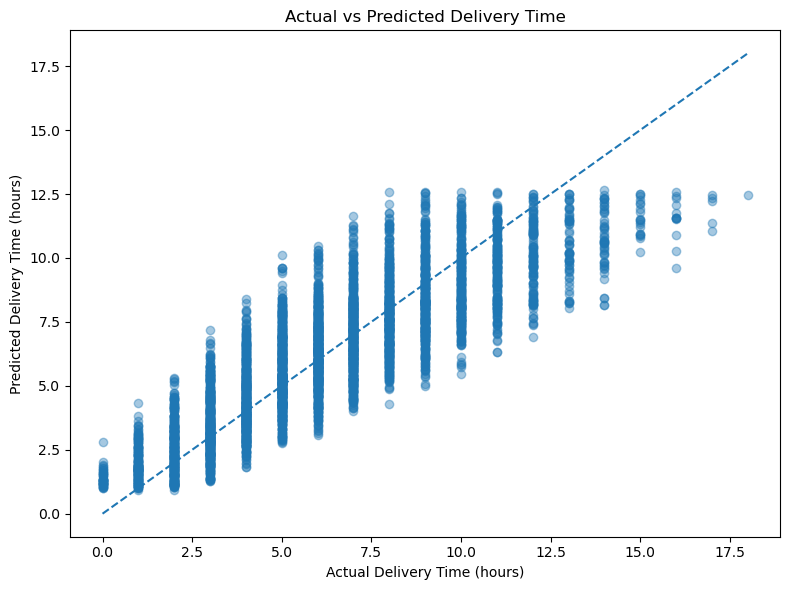

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_linear,
    alpha=0.4
)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.title("Actual vs Predicted Delivery Time")
plt.xlabel("Actual Delivery Time (hours)")
plt.ylabel("Predicted Delivery Time (hours)")

plt.tight_layout()
plt.show()

In [17]:
# Calculate prediction errors
residuals = y_test - y_pred_linear

print("===== RESIDUAL ANALYSIS =====")

print("Mean Residual:",
      round(residuals.mean(), 2), "hours")

print("Minimum Residual:",
      round(residuals.min(), 2), "hours")

print("Maximum Residual:",
      round(residuals.max(), 2), "hours")

print("Residual Standard Deviation:",
      round(residuals.std(), 2), "hours")

===== RESIDUAL ANALYSIS =====
Mean Residual: 0.04 hours
Minimum Residual: -5.13 hours
Maximum Residual: 6.39 hours
Residual Standard Deviation: 1.62 hours


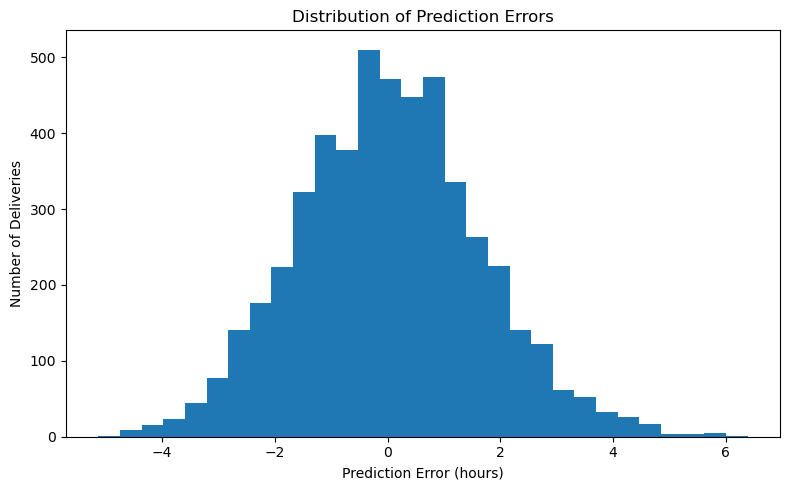

In [18]:
plt.figure(figsize=(8, 5))

plt.hist(residuals, bins=30)

plt.title("Distribution of Prediction Errors")
plt.xlabel("Prediction Error (hours)")
plt.ylabel("Number of Deliveries")

plt.tight_layout()
plt.show()

In [19]:
# Check the most common values for categorical features

print("Most common delivery partner:")
print(df["delivery_partner"].value_counts().head())

print("\nMost common package type:")
print(df["package_type"].value_counts().head())

print("\nMost common vehicle type:")
print(df["vehicle_type"].value_counts().head())

print("\nMost common region:")
print(df["region"].value_counts().head())

Most common delivery partner:
delivery_partner
xpressbees    2826
fedex         2818
dhl           2802
ekart         2801
blue dart     2798
Name: count, dtype: int64

Most common package type:
package_type
fragile items       2848
pharmacy            2810
documents           2805
automobile parts    2795
electronics         2792
Name: count, dtype: int64

Most common vehicle type:
vehicle_type
ev bike    4218
van        4187
scooter    4174
bike       4160
truck      4145
Name: count, dtype: int64

Most common region:
region
west       5095
central    5060
south      4977
north      4949
east       4919
Name: count, dtype: int64


In [20]:
# Create optimization scenarios

import itertools

delivery_modes = df["delivery_mode"].unique()
delivery_partners = df["delivery_partner"].unique()
vehicle_types = df["vehicle_type"].unique()

scenarios = []

for mode, partner, vehicle in itertools.product(
    delivery_modes,
    delivery_partners,
    vehicle_types
):
    
    scenarios.append({
        "delivery_partner": partner,
        "package_type": "fragile items",
        "vehicle_type": vehicle,
        "delivery_mode": mode,
        "region": "central",
        "weather_condition": "rainy",
        "distance_km": 200,
        "package_weight_kg": 10
    })

scenario_df = pd.DataFrame(scenarios)

# Predict delivery time for every scenario
scenario_df["predicted_delivery_time"] = (
    linear_model.predict(scenario_df)
)

# Sort from fastest to slowest
scenario_results = scenario_df.sort_values(
    "predicted_delivery_time"
)

print("===== TOP 15 OPTIMIZATION SCENARIOS =====")
print(
    scenario_results[
        [
            "delivery_partner",
            "vehicle_type",
            "delivery_mode",
            "predicted_delivery_time"
        ]
    ].head(15)
)

===== TOP 15 OPTIMIZATION SCENARIOS =====
    delivery_partner vehicle_type delivery_mode  predicted_delivery_time
94             fedex      ev bike       express                 8.849070
148            fedex      ev bike       two day                 8.858397
100     ecom express      ev bike       express                 8.870729
40             fedex      ev bike      same day                 8.877648
154     ecom express      ev bike       two day                 8.880056
58         delhivery      ev bike       express                 8.881737
112        delhivery      ev bike       two day                 8.891064
202            fedex      ev bike      standard                 8.897537
46      ecom express      ev bike      same day                 8.899307
91             fedex       ev van       express                 8.906687
106            ekart      ev bike       express                 8.908085
4          delhivery      ev bike      same day                 8.910315
92       

In [21]:
# Add historical delay rate for each delivery mode
mode_delay_rates = (
    df.groupby("delivery_mode")["delayed"]
    .apply(lambda x: (x == "yes").mean() * 100)
)

# Add delay rate to scenario results
scenario_results["historical_delay_rate"] = (
    scenario_results["delivery_mode"]
    .map(mode_delay_rates)
)

# Display the scenarios
optimization_results = scenario_results[
    [
        "delivery_partner",
        "vehicle_type",
        "delivery_mode",
        "predicted_delivery_time",
        "historical_delay_rate"
    ]
].copy()

print("===== OPTIMIZATION SCENARIO ANALYSIS =====")
print(optimization_results.head(15))

===== OPTIMIZATION SCENARIO ANALYSIS =====
    delivery_partner vehicle_type delivery_mode  predicted_delivery_time  \
94             fedex      ev bike       express                 8.849070   
148            fedex      ev bike       two day                 8.858397   
100     ecom express      ev bike       express                 8.870729   
40             fedex      ev bike      same day                 8.877648   
154     ecom express      ev bike       two day                 8.880056   
58         delhivery      ev bike       express                 8.881737   
112        delhivery      ev bike       two day                 8.891064   
202            fedex      ev bike      standard                 8.897537   
46      ecom express      ev bike      same day                 8.899307   
91             fedex       ev van       express                 8.906687   
106            ekart      ev bike       express                 8.908085   
4          delhivery      ev bike      same d

In [22]:
# ==========================================
# CELL 1: DEFINE BUSINESS SCENARIOS
# ==========================================

scenarios = {
    "Normal Shipment": {
        "distance_km": 50,
        "package_weight_kg": 5,
        "package_type": "electronics",
        "region": "central",
        "weather_condition": "clear"
    },

    "Long Distance Shipment": {
        "distance_km": 250,
        "package_weight_kg": 10,
        "package_type": "electronics",
        "region": "north",
        "weather_condition": "clear"
    },

    "Stormy Weather Shipment": {
        "distance_km": 100,
        "package_weight_kg": 5,
        "package_type": "electronics",
        "region": "central",
        "weather_condition": "stormy"
    },

    "Urgent Shipment": {
        "distance_km": 150,
        "package_weight_kg": 5,
        "package_type": "electronics",
        "region": "west",
        "weather_condition": "clear"
    }
}

print("Number of scenarios:", len(scenarios))

for scenario, details in scenarios.items():
    print("\n", scenario)
    print(details)

Number of scenarios: 4

 Normal Shipment
{'distance_km': 50, 'package_weight_kg': 5, 'package_type': 'electronics', 'region': 'central', 'weather_condition': 'clear'}

 Long Distance Shipment
{'distance_km': 250, 'package_weight_kg': 10, 'package_type': 'electronics', 'region': 'north', 'weather_condition': 'clear'}

 Stormy Weather Shipment
{'distance_km': 100, 'package_weight_kg': 5, 'package_type': 'electronics', 'region': 'central', 'weather_condition': 'stormy'}

 Urgent Shipment
{'distance_km': 150, 'package_weight_kg': 5, 'package_type': 'electronics', 'region': 'west', 'weather_condition': 'clear'}


In [23]:
# ==========================================
# CELL 2: CREATE OPERATIONAL COMBINATIONS
# ==========================================

import itertools
import pandas as pd

# Get unique operational options from our dataset
partners = df["delivery_partner"].unique()
vehicles = df["vehicle_type"].unique()
modes = df["delivery_mode"].unique()

print("Delivery Partners:", list(partners))
print("Vehicle Types:", list(vehicles))
print("Delivery Modes:", list(modes))

# Create every possible combination
operational_combinations = list(
    itertools.product(partners, vehicles, modes)
)

print("\nTotal operational combinations:",
      len(operational_combinations))

Delivery Partners: ['delhivery', 'xpressbees', 'shadowfax', 'dhl', 'amazon logistics', 'blue dart', 'fedex', 'ecom express', 'ekart']
Vehicle Types: ['bike', 'ev van', 'truck', 'van', 'ev bike', 'scooter']
Delivery Modes: ['same day', 'express', 'two day', 'standard']

Total operational combinations: 216


In [24]:
# ==========================================
# CELL 3: BUILD SCENARIO COMBINATIONS
# ==========================================

scenario_rows = []

for scenario_name, scenario_details in scenarios.items():

    for partner, vehicle, mode in operational_combinations:

        row = {
            "scenario": scenario_name,
            "delivery_partner": partner,
            "vehicle_type": vehicle,
            "delivery_mode": mode,
            "distance_km": scenario_details["distance_km"],
            "package_weight_kg": scenario_details["package_weight_kg"],
            "package_type": scenario_details["package_type"],
            "region": scenario_details["region"],
            "weather_condition": scenario_details["weather_condition"]
        }

        scenario_rows.append(row)

scenario_df = pd.DataFrame(scenario_rows)

print("Scenario dataset shape:", scenario_df.shape)

print("\nColumns:")
print(scenario_df.columns.tolist())

print("\nFirst 10 rows:")
print(scenario_df.head(10))

Scenario dataset shape: (864, 9)

Columns:
['scenario', 'delivery_partner', 'vehicle_type', 'delivery_mode', 'distance_km', 'package_weight_kg', 'package_type', 'region', 'weather_condition']

First 10 rows:
          scenario delivery_partner vehicle_type delivery_mode  distance_km  \
0  Normal Shipment        delhivery         bike      same day           50   
1  Normal Shipment        delhivery         bike       express           50   
2  Normal Shipment        delhivery         bike       two day           50   
3  Normal Shipment        delhivery         bike      standard           50   
4  Normal Shipment        delhivery       ev van      same day           50   
5  Normal Shipment        delhivery       ev van       express           50   
6  Normal Shipment        delhivery       ev van       two day           50   
7  Normal Shipment        delhivery       ev van      standard           50   
8  Normal Shipment        delhivery        truck      same day           50   
9 

In [25]:
# ==========================================
# CELL 4: PREDICT DELIVERY TIME
# ==========================================

# Features must be in the same order used during model training
scenario_features = [
    "delivery_partner",
    "package_type",
    "vehicle_type",
    "delivery_mode",
    "region",
    "weather_condition",
    "distance_km",
    "package_weight_kg"
]

# Predict delivery time for every scenario and operational combination
scenario_df["predicted_delivery_time"] = random_forest_model.predict(
    scenario_df[scenario_features]
)

print("Predictions created successfully.")

print("\nPrediction summary:")
print(scenario_df["predicted_delivery_time"].describe())

print("\nFirst 10 predictions:")
print(
    scenario_df[
        [
            "scenario",
            "delivery_partner",
            "vehicle_type",
            "delivery_mode",
            "predicted_delivery_time"
        ]
    ].head(10)
)

Predictions created successfully.

Prediction summary:
count    864.000000
mean       5.216921
std        1.926782
min        1.720000
25%        3.860000
50%        5.925000
75%        6.810000
max        7.980000
Name: predicted_delivery_time, dtype: float64

First 10 predictions:
          scenario delivery_partner vehicle_type delivery_mode  \
0  Normal Shipment        delhivery         bike      same day   
1  Normal Shipment        delhivery         bike       express   
2  Normal Shipment        delhivery         bike       two day   
3  Normal Shipment        delhivery         bike      standard   
4  Normal Shipment        delhivery       ev van      same day   
5  Normal Shipment        delhivery       ev van       express   
6  Normal Shipment        delhivery       ev van       two day   
7  Normal Shipment        delhivery       ev van      standard   
8  Normal Shipment        delhivery        truck      same day   
9  Normal Shipment        delhivery        truck       e

In [31]:
# Calculate historical delay rate for each operational combination

delay_risk = (
    df.groupby(
        [
            "delivery_partner",
            "vehicle_type",
            "delivery_mode",
            "weather_condition"
        ]
    )["delayed"]
    .apply(lambda x: (x == "yes").mean() * 100)
    .reset_index(name="historical_delay_rate")
)

# Merge historical delay risk into scenario dataset

scenario_df = scenario_df.drop(
    columns=["historical_delay_rate"],
    errors="ignore"
)

scenario_df = scenario_df.merge(
    delay_risk,
    on=[
        "delivery_partner",
        "vehicle_type",
        "delivery_mode",
        "weather_condition"
    ],
    how="left"
)

print("Scenario-specific historical delay risk added successfully.")

print(
    scenario_df[
        [
            "scenario",
            "delivery_partner",
            "vehicle_type",
            "delivery_mode",
            "weather_condition",
            "historical_delay_rate"
        ]
    ].head(15)
)

Scenario-specific historical delay risk added successfully.
                   scenario delivery_partner vehicle_type delivery_mode  \
0   Stormy Weather Shipment        shadowfax         bike       express   
1   Stormy Weather Shipment        shadowfax      scooter       express   
2   Stormy Weather Shipment        shadowfax      ev bike       express   
3    Long Distance Shipment       xpressbees      scooter       express   
4    Long Distance Shipment       xpressbees       ev van       express   
5   Stormy Weather Shipment        shadowfax        truck       express   
6    Long Distance Shipment            ekart      ev bike       express   
7   Stormy Weather Shipment        shadowfax       ev van       express   
8   Stormy Weather Shipment     ecom express        truck       express   
9   Stormy Weather Shipment              dhl       ev van       express   
10  Stormy Weather Shipment       xpressbees      scooter       express   
11  Stormy Weather Shipment        shado

In [32]:
# ==========================================
# CELL 6: ADD ESTIMATED DELIVERY COST
# ==========================================

# Calculate historical average cost for each
# partner + vehicle + delivery mode combination
cost_lookup = (
    df.groupby(
        ["delivery_partner", "vehicle_type", "delivery_mode"]
    )["delivery_cost"]
    .mean()
)

# Map the historical average cost to each scenario
scenario_df["estimated_delivery_cost"] = [
    cost_lookup.get(
        (partner, vehicle, mode),
        df["delivery_cost"].mean()
    )
    for partner, vehicle, mode in zip(
        scenario_df["delivery_partner"],
        scenario_df["vehicle_type"],
        scenario_df["delivery_mode"]
    )
]

print("Estimated delivery cost added successfully.")

print("\nCost summary:")
print(
    scenario_df["estimated_delivery_cost"].describe()
)

print("\nSample scenario decisions:")
print(
    scenario_df[
        [
            "scenario",
            "delivery_partner",
            "vehicle_type",
            "delivery_mode",
            "predicted_delivery_time",
            "historical_delay_rate",
            "estimated_delivery_cost"
        ]
    ].head(10)
)

Estimated delivery cost added successfully.

Cost summary:
count     864.000000
mean      865.048737
std        61.601714
min       708.547797
25%       825.010541
50%       862.942182
75%       903.178249
max      1068.201144
Name: estimated_delivery_cost, dtype: float64

Sample scenario decisions:
                  scenario delivery_partner vehicle_type delivery_mode  \
0  Stormy Weather Shipment        shadowfax         bike       express   
1  Stormy Weather Shipment        shadowfax      scooter       express   
2  Stormy Weather Shipment        shadowfax      ev bike       express   
3   Long Distance Shipment       xpressbees      scooter       express   
4   Long Distance Shipment       xpressbees       ev van       express   
5  Stormy Weather Shipment        shadowfax        truck       express   
6   Long Distance Shipment            ekart      ev bike       express   
7  Stormy Weather Shipment        shadowfax       ev van       express   
8  Stormy Weather Shipment     ec

In [38]:
# Normalize optimization factors

# Lower delivery time is better
scenario_df["time_score"] = (
    1 - (
        (scenario_df["predicted_delivery_time"] -
         scenario_df["predicted_delivery_time"].min())
        /
        (scenario_df["predicted_delivery_time"].max() -
         scenario_df["predicted_delivery_time"].min())
    )
)

# Lower delay risk is better
scenario_df["delay_score"] = (
    1 - (
        (scenario_df["adjusted_delay_rate"] -
         scenario_df["adjusted_delay_rate"].min())
        /
        (scenario_df["adjusted_delay_rate"].max() -
         scenario_df["adjusted_delay_rate"].min())
    )
)

# Lower delivery cost is better
scenario_df["cost_score"] = (
    1 - (
        (scenario_df["estimated_delivery_cost"] -
         scenario_df["estimated_delivery_cost"].min())
        /
        (scenario_df["estimated_delivery_cost"].max() -
         scenario_df["estimated_delivery_cost"].min())
    )
)

print("Normalization completed successfully.")

print(
    scenario_df[
        [
            "scenario",
            "delivery_partner",
            "vehicle_type",
            "delivery_mode",
            "weather_condition",
            "time_score",
            "delay_score",
            "cost_score"
        ]
    ].head(15)
)

Normalization completed successfully.
                   scenario  delivery_partner vehicle_type delivery_mode  \
0   Stormy Weather Shipment         shadowfax       ev van      same day   
1   Stormy Weather Shipment         shadowfax         bike       express   
2   Stormy Weather Shipment         shadowfax      scooter       express   
3   Stormy Weather Shipment               dhl        truck      same day   
4   Stormy Weather Shipment         shadowfax      ev bike       express   
5   Stormy Weather Shipment         shadowfax        truck       express   
6   Stormy Weather Shipment  amazon logistics      ev bike      same day   
7   Stormy Weather Shipment         shadowfax       ev van       express   
8   Stormy Weather Shipment         blue dart         bike      same day   
9   Stormy Weather Shipment      ecom express        truck       express   
10  Stormy Weather Shipment               dhl       ev van       express   
11  Stormy Weather Shipment        xpressbees     

In [39]:
# Create a combined optimization score

scenario_df["optimization_score"] = (
    0.40 * scenario_df["time_score"] +
    0.35 * scenario_df["delay_score"] +
    0.25 * scenario_df["cost_score"]
)

scenario_df = scenario_df.sort_values(
    "optimization_score",
    ascending=False
)

print("Optimization score calculated successfully.")
print(
    scenario_df[
        [
            "scenario",
            "delivery_partner",
            "vehicle_type",
            "delivery_mode",
            "predicted_delivery_time",
            "historical_delay_rate",
            "estimated_delivery_cost",
            "optimization_score"
        ]
    ].head(15)
)

Optimization score calculated successfully.
            scenario  delivery_partner vehicle_type delivery_mode  \
863  Normal Shipment             fedex      scooter      standard   
862  Normal Shipment               dhl          van      standard   
861  Normal Shipment         delhivery         bike      standard   
860  Normal Shipment             fedex          van       two day   
859  Normal Shipment         delhivery        truck       two day   
858  Normal Shipment             fedex        truck       two day   
857  Normal Shipment         blue dart       ev van      standard   
856  Normal Shipment        xpressbees          van      standard   
855  Normal Shipment             fedex          van      standard   
854  Normal Shipment         blue dart          van      standard   
853  Normal Shipment         delhivery        truck      standard   
852  Normal Shipment      ecom express        truck       two day   
851  Normal Shipment         blue dart      ev bike      st

In [40]:
# Rank scenarios from best to worst

ranked_scenarios = scenario_df.copy()

ranked_scenarios["rank"] = range(1, len(ranked_scenarios) + 1)

print("===== TOP 15 OPTIMIZED SCENARIOS =====")

print(
    ranked_scenarios[
        [
            "rank",
            "scenario",
            "delivery_partner",
            "vehicle_type",
            "delivery_mode",
            "distance_km",
            "package_weight_kg",
            "package_type",
            "region",
            "weather_condition",
            "predicted_delivery_time",
            "historical_delay_rate",
            "estimated_delivery_cost",
            "optimization_score"
        ]
    ].head(15)
)

===== TOP 15 OPTIMIZED SCENARIOS =====
     rank         scenario  delivery_partner vehicle_type delivery_mode  \
863     1  Normal Shipment             fedex      scooter      standard   
862     2  Normal Shipment               dhl          van      standard   
861     3  Normal Shipment         delhivery         bike      standard   
860     4  Normal Shipment             fedex          van       two day   
859     5  Normal Shipment         delhivery        truck       two day   
858     6  Normal Shipment             fedex        truck       two day   
857     7  Normal Shipment         blue dart       ev van      standard   
856     8  Normal Shipment        xpressbees          van      standard   
855     9  Normal Shipment             fedex          van      standard   
854    10  Normal Shipment         blue dart          van      standard   
853    11  Normal Shipment         delhivery        truck      standard   
852    12  Normal Shipment      ecom express        truck    

In [36]:
# Check how many historical deliveries support each scenario combination

combination_counts = (
    df.groupby(
        [
            "delivery_partner",
            "vehicle_type",
            "delivery_mode",
            "weather_condition"
        ]
    )
    .size()
    .reset_index(name="historical_deliveries")
)

scenario_df = scenario_df.merge(
    combination_counts,
    on=[
        "delivery_partner",
        "vehicle_type",
        "delivery_mode",
        "weather_condition"
    ],
    how="left"
)

print("===== HISTORICAL SAMPLE SIZE CHECK =====")

print(
    scenario_df[
        [
            "scenario",
            "delivery_partner",
            "vehicle_type",
            "delivery_mode",
            "weather_condition",
            "historical_deliveries",
            "historical_delay_rate"
        ]
    ].head(20)
)

===== HISTORICAL SAMPLE SIZE CHECK =====
                   scenario  delivery_partner vehicle_type delivery_mode  \
0   Stormy Weather Shipment         shadowfax       ev van      same day   
1   Stormy Weather Shipment         shadowfax         bike       express   
2   Stormy Weather Shipment         shadowfax      scooter       express   
3   Stormy Weather Shipment               dhl        truck      same day   
4   Stormy Weather Shipment         shadowfax      ev bike       express   
5   Stormy Weather Shipment         shadowfax        truck       express   
6   Stormy Weather Shipment  amazon logistics      ev bike      same day   
7   Stormy Weather Shipment         shadowfax       ev van       express   
8   Stormy Weather Shipment         blue dart         bike      same day   
9   Stormy Weather Shipment      ecom express        truck       express   
10  Stormy Weather Shipment               dhl       ev van       express   
11  Stormy Weather Shipment        xpressbees  

In [37]:
# Calculate broader weather-based delay rate

weather_delay_rate = (
    df.groupby("weather_condition")["delayed"]
    .apply(lambda x: (x == "yes").mean() * 100)
    .reset_index(name="weather_delay_rate")
)

# Add weather-level delay rate to scenarios

scenario_df = scenario_df.drop(
    columns=["weather_delay_rate"],
    errors="ignore"
)

scenario_df = scenario_df.merge(
    weather_delay_rate,
    on="weather_condition",
    how="left"
)

# Create weighted delay risk

scenario_df["adjusted_delay_rate"] = (
    0.60 * scenario_df["historical_delay_rate"]
    + 0.40 * scenario_df["weather_delay_rate"]
)

print("Adjusted delay risk calculated successfully.")

print(
    scenario_df[
        [
            "scenario",
            "delivery_partner",
            "vehicle_type",
            "delivery_mode",
            "weather_condition",
            "historical_deliveries",
            "historical_delay_rate",
            "weather_delay_rate",
            "adjusted_delay_rate"
        ]
    ].head(20)
)

Adjusted delay risk calculated successfully.
                   scenario  delivery_partner vehicle_type delivery_mode  \
0   Stormy Weather Shipment         shadowfax       ev van      same day   
1   Stormy Weather Shipment         shadowfax         bike       express   
2   Stormy Weather Shipment         shadowfax      scooter       express   
3   Stormy Weather Shipment               dhl        truck      same day   
4   Stormy Weather Shipment         shadowfax      ev bike       express   
5   Stormy Weather Shipment         shadowfax        truck       express   
6   Stormy Weather Shipment  amazon logistics      ev bike      same day   
7   Stormy Weather Shipment         shadowfax       ev van       express   
8   Stormy Weather Shipment         blue dart         bike      same day   
9   Stormy Weather Shipment      ecom express        truck       express   
10  Stormy Weather Shipment               dhl       ev van       express   
11  Stormy Weather Shipment        xpressbe

In [41]:
# Select the best operational option for each business scenario

best_scenarios = (
    scenario_df
    .loc[
        scenario_df.groupby("scenario")["optimization_score"]
        .idxmax()
    ]
    .sort_values("optimization_score", ascending=False)
)

print("===== BEST OPTION FOR EACH SCENARIO =====")

print(
    best_scenarios[
        [
            "scenario",
            "delivery_partner",
            "vehicle_type",
            "delivery_mode",
            "distance_km",
            "package_weight_kg",
            "package_type",
            "region",
            "weather_condition",
            "predicted_delivery_time",
            "adjusted_delay_rate",
            "estimated_delivery_cost",
            "optimization_score"
        ]
    ]
)

===== BEST OPTION FOR EACH SCENARIO =====
                    scenario delivery_partner vehicle_type delivery_mode  \
863          Normal Shipment            fedex      scooter      standard   
735          Urgent Shipment              dhl          van      standard   
637   Long Distance Shipment            fedex      scooter      standard   
605  Stormy Weather Shipment            fedex      scooter      standard   

     distance_km  package_weight_kg package_type   region weather_condition  \
863           50                  5  electronics  central             clear   
735          150                  5  electronics     west             clear   
637          250                 10  electronics    north             clear   
605          100                  5  electronics  central            stormy   

     predicted_delivery_time  adjusted_delay_rate  estimated_delivery_cost  \
863                     2.21             6.973812               708.547797   
735                     4

In [42]:
# Check historical support for each scenario

scenario_support = (
    df.groupby(
        ["delivery_mode", "distance_km", "package_weight_kg",
         "package_type", "region", "weather_condition"]
    )
    .size()
    .reset_index(name="historical_count")
)

print("===== HISTORICAL SUPPORT CHECK =====")
print(scenario_support.describe())

===== HISTORICAL SUPPORT CHECK =====
        distance_km  package_weight_kg  historical_count
count  24999.000000       24999.000000      24999.000000
mean     150.396140          25.145662          1.000040
std       86.406767          14.368902          0.006325
min        3.600000           0.670000          1.000000
25%       75.900000          12.680000          1.000000
50%      151.000000          25.140000          1.000000
75%      224.900000          37.660000          1.000000
max      297.100000          49.520000          2.000000


In [43]:
# Check historical support using key operational factors

operational_support = (
    df.groupby(
        ["delivery_partner",
         "vehicle_type",
         "delivery_mode",
         "weather_condition"]
    )
    .size()
    .reset_index(name="historical_count")
)

print("===== OPERATIONAL HISTORICAL SUPPORT =====")
print(operational_support["historical_count"].describe())

print("\nMinimum historical observations:",
      operational_support["historical_count"].min())

print("Maximum historical observations:",
      operational_support["historical_count"].max())

===== OPERATIONAL HISTORICAL SUPPORT =====
count    1296.000000
mean       19.290123
std         4.337403
min         8.000000
25%        16.000000
50%        19.000000
75%        22.000000
max        36.000000
Name: historical_count, dtype: float64

Minimum historical observations: 8
Maximum historical observations: 36


In [44]:
# Add historical support to scenario combinations

scenario_df = scenario_df.merge(
    operational_support,
    on=[
        "delivery_partner",
        "vehicle_type",
        "delivery_mode",
        "weather_condition"
    ],
    how="left"
)

print("===== SCENARIO SUPPORT ADDED =====")
print(
    scenario_df[
        [
            "scenario",
            "delivery_partner",
            "vehicle_type",
            "delivery_mode",
            "weather_condition",
            "historical_count"
        ]
    ].head(15)
)

===== SCENARIO SUPPORT ADDED =====
           scenario  delivery_partner vehicle_type delivery_mode  \
0   Normal Shipment             fedex      scooter      standard   
1   Normal Shipment               dhl          van      standard   
2   Normal Shipment         delhivery         bike      standard   
3   Normal Shipment             fedex          van       two day   
4   Normal Shipment         delhivery        truck       two day   
5   Normal Shipment             fedex        truck       two day   
6   Normal Shipment         blue dart       ev van      standard   
7   Normal Shipment        xpressbees          van      standard   
8   Normal Shipment             fedex          van      standard   
9   Normal Shipment         blue dart          van      standard   
10  Normal Shipment         delhivery        truck      standard   
11  Normal Shipment      ecom express        truck       two day   
12  Normal Shipment         blue dart      ev bike      standard   
13  Normal Sh

In [45]:
# Apply minimum historical support threshold

MIN_SUPPORT = 10

scenario_supported = scenario_df[
    scenario_df["historical_count"] >= MIN_SUPPORT
].copy()

print("===== SUPPORT FILTER =====")
print("Minimum support required:", MIN_SUPPORT)
print("Scenarios before filtering:", len(scenario_df))
print("Scenarios after filtering:", len(scenario_supported))
print(
    "Scenarios removed:",
    len(scenario_df) - len(scenario_supported)
)

===== SUPPORT FILTER =====
Minimum support required: 10
Scenarios before filtering: 864
Scenarios after filtering: 859
Scenarios removed: 5


In [49]:
# Apply realistic logistics business constraints

scenario_constrained = scenario_supported.copy()

# Constraint 1:
# Two-wheelers should not be used for long-distance shipments
scenario_constrained = scenario_constrained[
    ~(
        (scenario_constrained["scenario"] == "Long Distance Shipment") &
        (scenario_constrained["vehicle_type"].isin(
            ["bike", "scooter", "ev bike"]
        ))
    )
]

# Constraint 2:
# Two-wheelers should not be used during stormy weather
scenario_constrained = scenario_constrained[
    ~(
        (scenario_constrained["weather_condition"] == "stormy") &
        (scenario_constrained["vehicle_type"].isin(
            ["bike", "scooter", "ev bike"]
        ))
    )
]

# Constraint 3:
# Urgent shipments should use faster delivery modes
scenario_constrained = scenario_constrained[
    ~(
        (scenario_constrained["scenario"] == "Urgent Shipment") &
        (scenario_constrained["delivery_mode"].isin(
            ["two day", "standard"]
        ))
    )
]

print("===== BUSINESS CONSTRAINTS =====")
print("Scenarios before constraints:", len(scenario_supported))
print("Scenarios after constraints:", len(scenario_constrained))
print(
    "Combinations removed:",
    len(scenario_supported) - len(scenario_constrained)
)

===== BUSINESS CONSTRAINTS =====
Scenarios before constraints: 859
Scenarios after constraints: 537
Combinations removed: 322


In [50]:
# Recalculate optimization score after business constraints

scenario_constrained["time_score"] = (
    1 - (
        scenario_constrained["predicted_delivery_time"]
        - scenario_constrained["predicted_delivery_time"].min()
    ) / (
        scenario_constrained["predicted_delivery_time"].max()
        - scenario_constrained["predicted_delivery_time"].min()
    )
)

scenario_constrained["delay_score"] = (
    1 - (
        scenario_constrained["adjusted_delay_rate"]
        - scenario_constrained["adjusted_delay_rate"].min()
    ) / (
        scenario_constrained["adjusted_delay_rate"].max()
        - scenario_constrained["adjusted_delay_rate"].min()
    )
)

scenario_constrained["cost_score"] = (
    1 - (
        scenario_constrained["estimated_delivery_cost"]
        - scenario_constrained["estimated_delivery_cost"].min()
    ) / (
        scenario_constrained["estimated_delivery_cost"].max()
        - scenario_constrained["estimated_delivery_cost"].min()
    )
)

# Weighted optimization score
scenario_constrained["optimization_score"] = (
    0.40 * scenario_constrained["time_score"] +
    0.30 * scenario_constrained["delay_score"] +
    0.30 * scenario_constrained["cost_score"]
)

print("===== FINAL OPTIMIZATION SCORE =====")
print(
    scenario_constrained[
        [
            "scenario",
            "delivery_partner",
            "vehicle_type",
            "delivery_mode",
            "predicted_delivery_time",
            "adjusted_delay_rate",
            "estimated_delivery_cost",
            "optimization_score"
        ]
    ].head(15)
)

===== FINAL OPTIMIZATION SCORE =====
           scenario  delivery_partner vehicle_type delivery_mode  \
0   Normal Shipment             fedex      scooter      standard   
1   Normal Shipment               dhl          van      standard   
2   Normal Shipment         delhivery         bike      standard   
3   Normal Shipment             fedex          van       two day   
4   Normal Shipment         delhivery        truck       two day   
5   Normal Shipment             fedex        truck       two day   
6   Normal Shipment         blue dart       ev van      standard   
7   Normal Shipment        xpressbees          van      standard   
8   Normal Shipment             fedex          van      standard   
9   Normal Shipment         blue dart          van      standard   
10  Normal Shipment         delhivery        truck      standard   
11  Normal Shipment      ecom express        truck       two day   
12  Normal Shipment         blue dart      ev bike      standard   
13  Normal 

In [51]:
# Select the best operational option for each scenario

best_by_scenario = (
    scenario_constrained
    .sort_values(
        ["scenario", "optimization_score"],
        ascending=[True, False]
    )
    .groupby("scenario")
    .head(1)
    .reset_index(drop=True)
)

print("===== BEST OPTION FOR EACH SCENARIO =====")

print(
    best_by_scenario[
        [
            "scenario",
            "delivery_partner",
            "vehicle_type",
            "delivery_mode",
            "distance_km",
            "package_weight_kg",
            "package_type",
            "region",
            "weather_condition",
            "predicted_delivery_time",
            "adjusted_delay_rate",
            "estimated_delivery_cost",
            "historical_count",
            "optimization_score"
        ]
    ]
)

===== BEST OPTION FOR EACH SCENARIO =====
                  scenario delivery_partner vehicle_type delivery_mode  \
0   Long Distance Shipment            fedex        truck       two day   
1          Normal Shipment            fedex      scooter      standard   
2  Stormy Weather Shipment            fedex          van       two day   
3          Urgent Shipment     ecom express          van      same day   

   distance_km  package_weight_kg package_type   region weather_condition  \
0          250                 10  electronics    north             clear   
1           50                  5  electronics  central             clear   
2          100                  5  electronics  central            stormy   
3          150                  5  electronics     west             clear   

   predicted_delivery_time  adjusted_delay_rate  estimated_delivery_cost  \
0                     6.34             6.973812               750.565341   
1                     2.21             6.973812  

In [52]:
# Create final scenario recommendation table

final_recommendations = best_by_scenario[
    [
        "scenario",
        "delivery_partner",
        "vehicle_type",
        "delivery_mode",
        "distance_km",
        "package_weight_kg",
        "package_type",
        "region",
        "weather_condition",
        "predicted_delivery_time",
        "adjusted_delay_rate",
        "estimated_delivery_cost",
        "historical_count",
        "optimization_score"
    ]
].copy()

# Sort scenarios into a logical order
scenario_order = [
    "Normal Shipment",
    "Urgent Shipment",
    "Long Distance Shipment",
    "Stormy Weather Shipment"
]

final_recommendations["scenario"] = pd.Categorical(
    final_recommendations["scenario"],
    categories=scenario_order,
    ordered=True
)

final_recommendations = (
    final_recommendations
    .sort_values("scenario")
    .reset_index(drop=True)
)

print("===== FINAL SCENARIO RECOMMENDATIONS =====")
print(final_recommendations.round(2))

===== FINAL SCENARIO RECOMMENDATIONS =====
                  scenario delivery_partner vehicle_type delivery_mode  \
0          Normal Shipment            fedex      scooter      standard   
1          Urgent Shipment     ecom express          van      same day   
2   Long Distance Shipment            fedex        truck       two day   
3  Stormy Weather Shipment            fedex          van       two day   

   distance_km  package_weight_kg package_type   region weather_condition  \
0           50                  5  electronics  central             clear   
1          150                  5  electronics     west             clear   
2          250                 10  electronics    north             clear   
3          100                  5  electronics  central            stormy   

   predicted_delivery_time  adjusted_delay_rate  estimated_delivery_cost  \
0                     2.21                 6.97                   708.55   
1                     4.80                10.72 

In [53]:
# ===== CELL 18: BUSINESS IMPACT SUMMARY =====

print("===== BUSINESS IMPACT SUMMARY =====")

# Calculate average predicted delivery time
avg_predicted_time = final_recommendations["predicted_delivery_time"].mean()

# Calculate average estimated delivery cost
avg_estimated_cost = final_recommendations["estimated_delivery_cost"].mean()

# Calculate average adjusted delay risk
avg_delay_risk = final_recommendations["adjusted_delay_rate"].mean()

# Calculate average optimization score
avg_optimization_score = final_recommendations["optimization_score"].mean()

print("Average Predicted Delivery Time:",
      round(avg_predicted_time, 2), "hours")

print("Average Estimated Delivery Cost:",
      round(avg_estimated_cost, 2))

print("Average Adjusted Delay Risk:",
      round(avg_delay_risk, 2), "%")

print("Average Optimization Score:",
      round(avg_optimization_score, 2))

print("\n===== KEY BUSINESS INSIGHTS =====")

print(
    "1. The optimization framework identifies the most suitable "
    "delivery partner, vehicle type, and delivery mode for each scenario."
)

print(
    "2. The recommendations consider predicted delivery time, "
    "historical delay risk, estimated delivery cost, and historical support."
)

print(
    "3. Higher optimization scores indicate combinations that provide "
    "a better balance between delivery speed, reliability, and cost."
)

print(
    "4. Historical support is used to avoid recommending combinations "
    "with insufficient operational evidence."
)

print(
    "5. The final recommendations can help logistics managers make "
    "data-driven decisions for different shipment conditions."
)

===== BUSINESS IMPACT SUMMARY =====
Average Predicted Delivery Time: 5.04 hours
Average Estimated Delivery Cost: 761.01
Average Adjusted Delay Risk: 10.31 %
Average Optimization Score: 0.73

===== KEY BUSINESS INSIGHTS =====
1. The optimization framework identifies the most suitable delivery partner, vehicle type, and delivery mode for each scenario.
2. The recommendations consider predicted delivery time, historical delay risk, estimated delivery cost, and historical support.
3. Higher optimization scores indicate combinations that provide a better balance between delivery speed, reliability, and cost.
4. Historical support is used to avoid recommending combinations with insufficient operational evidence.
5. The final recommendations can help logistics managers make data-driven decisions for different shipment conditions.
